# Simplified Morphology + Spectroscopy Analysis

This notebook extracts hyperspectral image data from an Agilent IR file, segments particle candidates using thresholding, collapses each particle spectrum with PCA, matches the result against the OS cluster library, and writes the final particle composition results to CSV.

In [41]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from agilent_ir_file import AgilentIRFile
import agilent_to_python as a2p
from calc_pca import cpca
import spec_process as spec_p
import library_OS_fit as lib_OS
from skimage.measure import label, regionprops

DTYPE = np.float32

In [42]:
# Cell 2: Load the Agilent IR file and extract hyperspectral data
filename = r'C:\Users\Stephanie.Wang\Downloads\uog-2-q4\uog-2-q4.dmt'  # update this path to your file

reader = AgilentIRFile()
reader.read(filename)

wavenumbers = a2p.data_wns(reader).astype(DTYPE)
intensities = reader.intensities.astype(DTYPE)  # shape: (rows, cols, bands)
total_image = reader.total_image.astype(DTYPE)  # integrated absorbance image
metadata = reader.metadata

print('wavenumbers:', wavenumbers.shape)
print('intensities:', intensities.shape)
print('total_image:', total_image.shape)
print('metadata keys:', list(metadata.keys()) if isinstance(metadata, dict) else type(metadata))

wavenumbers: (1505,)
intensities: (1280, 1152, 1558)
total_image: (1280, 1152)
metadata keys: ['filename', 'xpixels', 'ypixels', 'xtiles', 'ytiles', 'numpts', 'fpasize', 'firstwavenumber', 'lastwavenumber', 'xlabel', 'ylabel', 'acqdatetime', 'datashape']


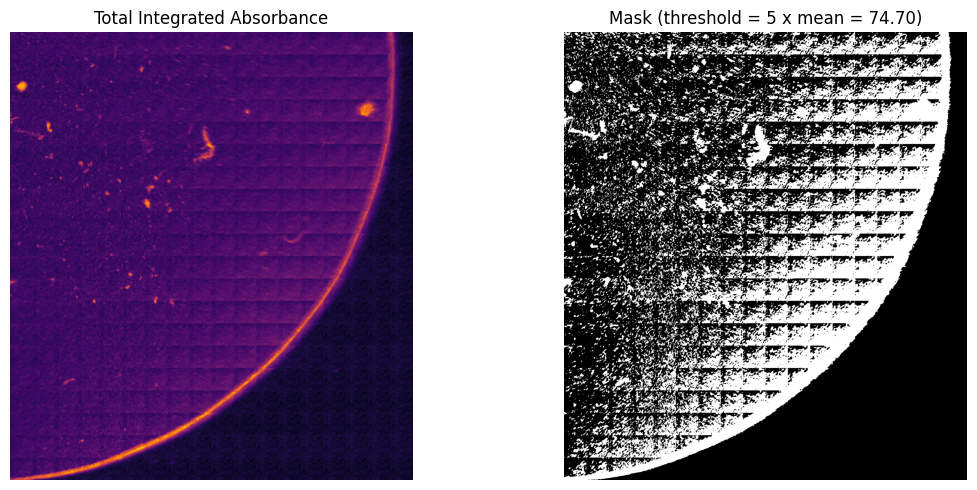

In [43]:
# Cell 3: Segment particle candidates by thresholding the total image
threshold = 5 * total_image.mean()
mask = total_image > threshold

# Display the total image and mask side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(total_image, cmap='inferno')
axes[0].set_title('Total Integrated Absorbance')
axes[0].axis('off')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'Mask (threshold = 5 x mean = {threshold:.2f})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [44]:
# Cell 4: Label particles and prepare matching functions
lbls, num_particles = label(mask, return_num=True)
props = regionprops(lbls)
print(f'Found {num_particles} particle candidates')

library_wavenos = lib_OS.get_lib_wns().astype(DTYPE)
library_spectra = pd.read_csv('OS_clusters_derint.csv').values.T.astype(DTYPE)

def match_library(spectrum):
    spectrum = (spectrum - np.mean(spectrum)) / (np.std(spectrum) + 1e-8)
    library_norm = (library_spectra - np.mean(library_spectra, axis=1, keepdims=True)) / (np.std(library_spectra, axis=1, keepdims=True) + 1e-8)
    correlations = np.dot(library_norm, spectrum) / spectrum.shape[0]
    if not np.isfinite(correlations).any():
        return -1, 0.0
    best_ix = int(np.nanargmax(correlations))
    best_pr = float(correlations[best_ix])
    return best_ix, best_pr

def analyze_particle(prop):
    coords = prop.coords
    spectra = []
    for row, col in coords:
        spectra.append(intensities[int(row), int(col)])
    spectra = np.asarray(spectra, dtype=DTYPE)
    if spectra.size == 0 or spectra.shape[1] == 0:
        return {'label': prop.label, 'polymer': 'small particle', 'best_pr': 0.0, 'pixel_count': 0, 'error': 'empty spectrum'}
    if spectra.shape[0] < 5:
        return {'label': prop.label, 'polymer': 'small particle', 'best_pr': 0.0, 'pixel_count': spectra.shape[0]}
    try:
        pca_components = cpca(spectra, range(1))
        if len(pca_components) == 0 or pca_components[0].size == 0:
            raise ValueError('PCA returned no components')
        representative = pca_components[0].astype(DTYPE)
    except Exception as e:
        return {'label': prop.label, 'polymer': 'error', 'best_pr': 0.0, 'pixel_count': spectra.shape[0], 'error': f'PCA failure: {e}'}
    if representative.shape[0] != wavenumbers.shape[0]:
        representative = np.interp(
            wavenumbers,
            np.linspace(wavenumbers[0], wavenumbers[-1], representative.shape[0]),
            representative
        ).astype(DTYPE)
    try:
        processed = spec_p.proc(representative, 5, 2, wavenumbers, library_wavenos)
        if processed.size == 0:
            raise ValueError('processed spectrum is empty')
        best_ix, best_pr = match_library(processed)
    except Exception as e:
        return {'label': prop.label, 'polymer': 'error', 'best_pr': 0.0, 'pixel_count': spectra.shape[0], 'error': f'processing failure: {e}'}
    try:
        polymer_name = lib_OS.catID(best_ix)
    except Exception:
        polymer_name = 'unknown polymer'
        best_pr = 0.0
    if best_pr < 0.3:
        polymer_name = f'{polymer_name} (low confidence)'
    return {'label': prop.label, 'polymer': polymer_name, 'best_pr': best_pr, 'pixel_count': spectra.shape[0]}

Found 6893 particle candidates


In [ ]:
# Cell 5: Analyze all particles and write results to CSV
results = []
for i, prop in enumerate(props, start=1):
    result = analyze_particle(prop)
    results.append(result)
    if i % 50 == 0 or i == len(props):
        print(f'Processed {i}/{len(props)} particles')

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('label').reset_index(drop=True)
output_path = 'simplified_particle_results.csv'
results_df.to_csv(output_path, index=False)

print(f'Wrote results to {output_path}')
results_df.head(20)

pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
Processed 50/6893 particles
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
pca calculated
Processed 100/6893 particles
pca calculated
pca calculated
pca calculate

,label,polymer,best_pr,pixel_count
0,1,small particle,0.000000,2
1,2,polyurethane (low confidence),0.022159,119
2,3,small particle,0.000000,3
3,4,silica (low confidence),0.038528,26
4,5,small particle,0.000000,3
5,6,small particle,0.000000,3
6,7,polypropylene (low confidence),0.045227,20
7,8,polyester,0.384190,149
8,9,small particle,0.000000,3
9,10,poly(phenylene sulfide) (low confidence),0.047039,54
